# Image Processing with python
There are several libraries that provide image processing functions
## OpenCV
OpenCV is a popular library for computer vision and image processing. It provides a wide range of functionalities, such as face detection, object recognition, feature extraction, image manipulation, video analysis, and more. OpenCV is written in C++ and has bindings for Python, Java, and other languages. OpenCV-Python is a Python wrapper for the original OpenCV C++ implementation. It uses Numpy, a highly optimized library for numerical operations, to store and manipulate image data. OpenCV-Python can be easily installed using pip, the Python package manager. To use OpenCV-Python, you just need to import the cv2 module and call its functions. Here is a simple example of how to read and display an image using OpenCV-Python:

```
import cv2
img = cv2.imread("path/to/image")
cv2.imshow("Display window", img)
k = cv2.waitKey(0) # Wait for a keystroke in the window
````

If you want to learn more about OpenCV-Python, you can check the [official documentation](https://pypi.org/project/opencv-python/), [the tutorials](https://opencv.org/get-started/), or the [online courses](https://docs.opencv.org/3.4/d0/de3/tutorial_py_intro.html). OpenCV-Python is a powerful and versatile tool for computer vision and image processing applications.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
cv2.useOptimized() 
import urllib.request

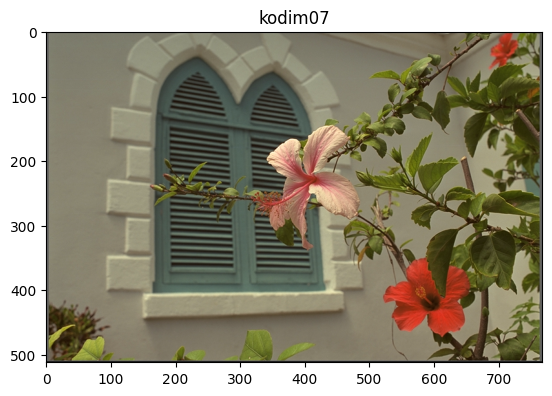

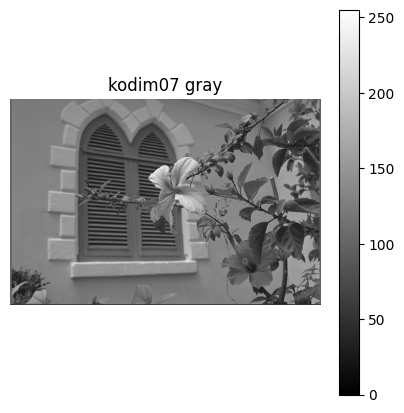

In [2]:


# read samle image from url
urllib.request.urlretrieve('https://r0k.us/graphics/kodak/kodak/kodim07.png', 'kodim07.png')
imBGR=cv2.imread('kodim07.png')
imRGB=cv2.cvtColor(imBGR, cv2.COLOR_BGR2RGB)
imgray=cv2.cvtColor(imRGB, cv2.COLOR_RGB2GRAY)

# show the image using opencv (BGR color space)
#cv2.imshow('image',imBGR)
#k=cv2.waitKey(0)
#cv2.destroyAllWindows()

# plot the image using matplotlib (RGB color space)
plt.figure()
plt.imshow(imRGB)
plt.title('kodim07')

# plot the gray image using matplotlib
plt.figure(figsize=(5,5))    
plt.imshow(imgray, cmap='gray')
plt.title('kodim07 gray')
#set the axis off
plt.axis('off')
plt.colorbar()


Let's define a function perfmorming histogram equalization

In [3]:

def imhist(img,scale=256):
    img=np.clip(img,0,scale-1)
    h=np.bincount(img.flatten())
    return h

def histeq(img,scale=256):
    h=imhist(img)
    T=np.cumsum(h)/np.prod(img.shape)*(scale-1)
    img_eq=np.floor(T[img])
    return np.int_(img_eq)



Text(0.5, 1.0, 'kodim07 gray equalized using opencv')

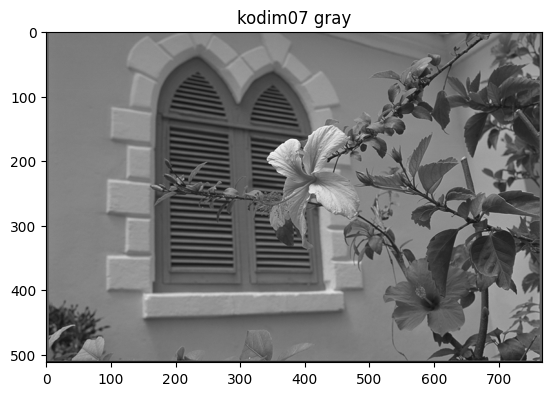

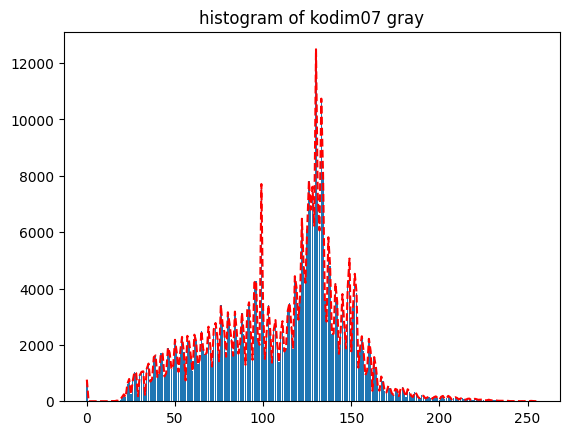

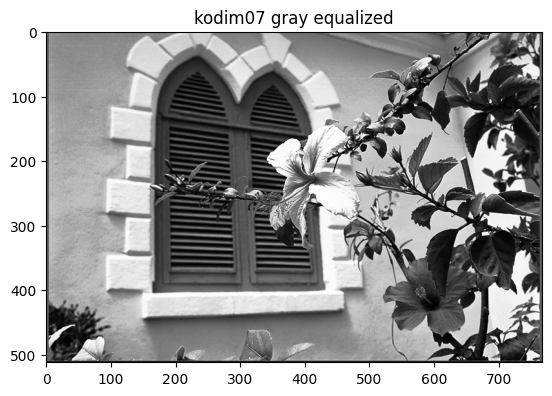

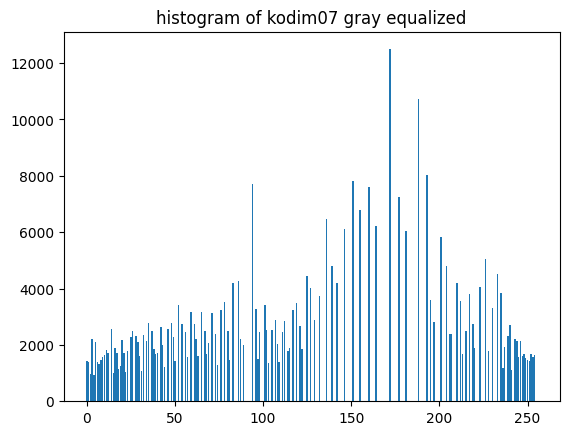

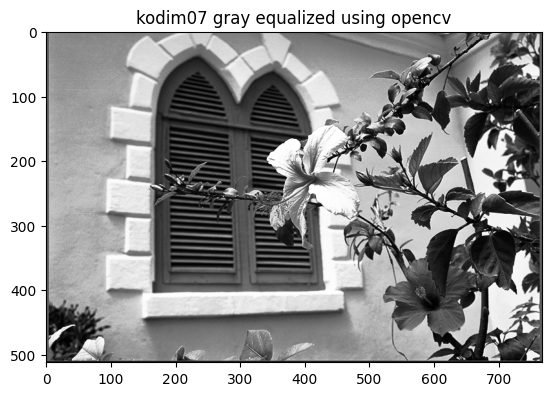

In [4]:
plt.figure()
plt.imshow(imgray, cmap='gray')
plt.title('kodim07 gray')

#using my own function
h=imhist(imgray)
#using opencv as an alternative
h2=cv2.calcHist([imgray],[0],None,[256],[0,256])

plt.figure()
plt.bar(np.arange(0,len(h)),h)
plt.plot(h2,'r--')
plt.title('histogram of kodim07 gray')

im_eq=histeq(imgray)
plt.figure()
plt.imshow(im_eq,cmap='gray')
plt.title('kodim07 gray equalized')

h_eq=imhist(im_eq)
plt.figure()
plt.bar(np.arange(0,len(h_eq)),h_eq)
plt.title('histogram of kodim07 gray equalized')

#perform histogram equalization using opencv
im_eq2=cv2.equalizeHist(imgray)
plt.figure()
plt.imshow(im_eq2,cmap='gray')
plt.title('kodim07 gray equalized using opencv')


# Other useful libraries
There are other two libs for image processing:
1. [scipy.ndimage](https://docs.scipy.org/doc/scipy/reference/ndimage.html)
2. [scikit-image](https://scikit-image.org)
3. [Pillow](https://pillow.readthedocs.io/en/stable/#)

In [7]:
import numpy as np
import scipy.ndimage as nd
from skimage import data, morphology, filters as imfilter
import skimage.metrics as metrics

Text(0.5, 1.0, 'cat')

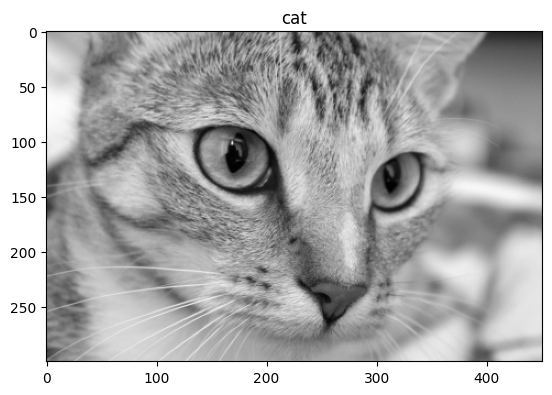

In [8]:
#load a sample image from skimage
img=data.cat()

if len(img.shape)>2 :
    img=cv2.cvtColor(img,cv2.COLOR_RGB2GRAY)

plt.figure()
plt.imshow(img,cmap='gray')
plt.title('cat')


scipy time=  0.005620002746582031
opencv time=  0.0015838146209716797
scikit time=  0.0055921077728271484


Text(0.5, 1.0, 'scikit')

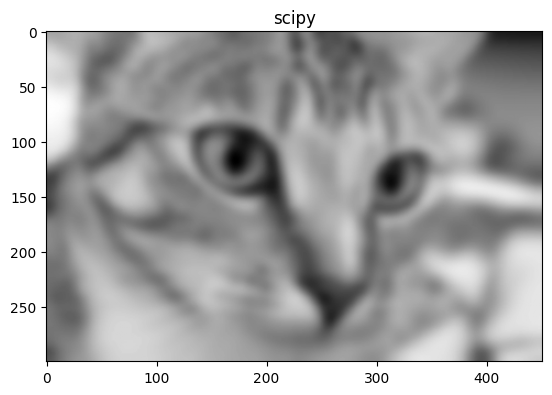

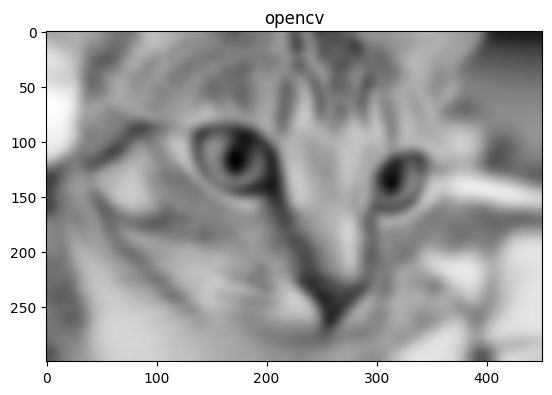

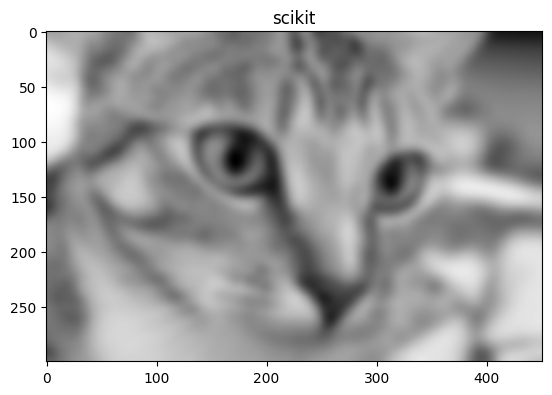

In [9]:
#let's do some profiling on simple spatial filtering
import time

#scipy
t0=time.time()
dst_scipy=nd.gaussian_filter(img,5)
t1=time.time()
print('scipy time= ', t1-t0)


#opencv
t0=time.time()
dst_cv2=cv2.GaussianBlur(img,(0,0),5)
t1=time.time()
print('opencv time= ', t1-t0)

#scikit
t0=time.time()
dst_skit= imfilter.gaussian(img,5)
t1=time.time()
print('scikit time= ', t1-t0)

plt.figure()
plt.imshow(dst_scipy,cmap='gray')
plt.title('scipy')

plt.figure()
plt.imshow(dst_cv2,cmap='gray')
plt.title('opencv')

plt.figure()
plt.imshow(dst_skit,cmap='gray')
plt.title('scikit')

#opencv is usually faster than scipy and scikit